# Import libraries.

In [1]:
import csv

import math
import numpy as np
import pandas as pd
import psycopg2
import neo4j
import json
from IPython.display import display

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import ast

# Postgres functions to query the cleanmovies database.

In [2]:
connection = psycopg2.connect(
    user = "postgres",
    password = "ucb",
    host = "postgres",
    port = "5432",
    database = "postgres"
)
cursor = connection.cursor()

In [3]:
def my_select_query_pandas(query, rollback_before_flag, rollback_after_flag):
    "function to run a select query and return rows in a pandas dataframe"
    
    if rollback_before_flag:
        connection.rollback()
    
    df = pd.read_sql_query(query, connection)
    
    if rollback_after_flag:
        connection.rollback()
    
    # fix the float columns that really should be integers
    
    for column in df:
    
        if df[column].dtype == "float64":

            fraction_flag = False

            for value in df[column].values:
                
                if not np.isnan(value):
                    if value - math.floor(value) != 0:
                        fraction_flag = True

            if not fraction_flag:
                df[column] = df[column].astype('Int64')
    
    return(df)

In [4]:
connection.rollback()

query = """

drop table if exists cleanmovies;

"""

cursor.execute(query)

connection.commit()


In [5]:
connection.rollback()

query = """

create table cleanmovies (
    index integer,
    title varchar(4000),
    budget varchar(4000),
    genres varchar(4000),
    id integer,
    keywords varchar(4000),
    overview varchar(4000),
    popularity varchar(4000),
    vote_average varchar(4000),
    vote_count varchar(4000),
    cast_ varchar(4000),
    director varchar(4000),
    executive_producer varchar(4000),
    writer varchar(4000),
    original_music_composer varchar(4000),
    director_photography varchar(4000),
    production_country varchar(4000),
    production_company varchar(4000),
    languages varchar(4000)  
)

"""

cursor.execute(query)

connection.commit()

In [6]:
connection.rollback()

query = """

copy cleanmovies
from '/user/projects/project-3-richardshelby/data/interim/cleanmovies.csv' delimiter ',' NULL '' csv header;

"""

cursor.execute(query)

connection.commit()

In [7]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from cleanmovies

"""
my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,0,102 Dalmatians,85000000,Comedy Family,10481,london england prison release from prison wome...,Get ready for a howling good time as an all ne...,9.895061,5.1,313,Glenn Close Ioan Gruffudd Alice Evans Tim McIn...,Kevin Lima,None,None,None,['Adrian Biddle'],['United States of America'],"['Walt Disney Pictures', 'Cruella Productions']",['English']
1,1,10 Cloverfield Lane,15000000,Thriller Science Fiction Drama,333371,kidnapping bunker paranoia basement survivalist,"After a car accident, Michelle awakens to find...",53.698682999999996,6.8,2468,Mary Elizabeth Winstead John Goodman John Gall...,Dan Trachtenberg,None,None,None,['Jeff Cutter'],['United States of America'],"['Bad Robot', 'Spectrum Effects', 'Paramount P...",['English']
2,2,10 Things I Hate About You,16000000,Comedy Romance Drama,4951,shakespeare sister high school cannabis deception,"Bianca, a tenth grader, has never gone on a da...",54.550275,7.3,1701,Heath Ledger Julia Stiles Joseph Gordon-Levitt...,Gil Junger,"['Seth Jaret', 'Jeffrey Chernov']","['Karen McCullah Lutz', 'Kirsten Smith']",['Richard Gibbs'],['Mark Irwin'],['United States of America'],"['Jaret Entertainment', 'Mad Chance', 'Touchst...","['Français', 'English']"
3,3,10th & Wolf,8000000,Action Crime Drama Mystery Thriller,13197,undercover mafia mobster crime family,A former street tough returns to his Philadelp...,3.9424639999999997,6.3,24,James Marsden Brian Dennehy Leo Rossi Dennis H...,Robert Moresco,None,"['Robert Moresco', 'Allan Steele']",None,None,['United States of America'],['Thinkfilm'],['English']
4,4,127 Hours,18000000,Adventure Drama Thriller,44115,mountains despair adventure utah alone,The true story of mountain climber Aron Ralsto...,52.464877,7.0,2606,James Franco Kate Mara Amber Tamblyn Cl\u00e9m...,Danny Boyle,"['Cameron McCracken', 'Bernard Bellew', 'Fran\...",None,['A. R. Rahman'],"['Enrique Chediak', 'Anthony Dod Mantle']","['United States of America', 'United Kingdom']","['Film4', 'Warner Bros.', 'Everest Entertainme...",['English']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,3218,Zombieland,23600000,Comedy Horror,19908,washington d.c. sister sister relationship pos...,Columbus has made a habit of running from what...,57.300674,7.2,3550,Jesse Eisenberg Woody Harrelson Emma Stone Abi...,Ruben Fleischer,"['Ryan Kavanaugh', 'Rhett Reese', 'Paul Wernic...","['Paul Wernick', 'Rhett Reese']",None,None,['United States of America'],"['Pariah', 'Relativity Media', 'Columbia Pictu...",['English']
3219,3219,Zookeeper,80000000,Comedy Romance Family,38317,talking animal scientist german accent ostrich...,A comedy about a zookeeper who might be great ...,27.462640000000004,5.3,498,Kevin James Rosario Dawson Sylvester Stallone ...,Frank Coraci,None,None,None,None,['United States of America'],"['Hey Eddie', 'Sony Pictures Releasing', 'Zook...",['English']
3220,3220,Zoolander,28000000,Comedy,9398,male model time magazine fashion show fashion ...,"Clear the runway for Derek Zoolander, VH1's th...",38.0958,6.1,1337,Ben Stiller Owen Wilson Christine Taylor Will ...,Ben Stiller,"['Lauren Zalaznick', 'Adam Schroeder', 'Joel G...",None,['David Arnold'],['Barry Peterson'],"['United States of America', 'Germany']","['NPV Entertainment', 'Red Hour Films', 'VH1 T...",['English']
3221,3221,Zoolander 2,50000000,Comedy,329833,stupidity sequel fashion male model fashion model,Derek and Hansel are modelling again when an o...,37.253774,4.7,797,Ben Stiller Owen Wilson Will Ferrell Pen\u00e9...,Ben Stiller,None,"['John Hamburg', 'Ben Stiller', 'Justin Therou...",None,None,['United States of America'],"['Red Hour Films', 'Scott Rudin Productions']",['English']


In [8]:
connection.rollback()

query = """

select *
from cleanmovies

"""

cursor.execute(query)

connection.rollback()

rows = cursor.fetchall()


# Get similarities from vector embeddings.

In [9]:
vector_embeddings = pd.read_csv("../../data/interim/Summarized_Text_3.0_Vector_Embeddings.csv")

In [10]:
vector_embeddings_clean = np.nan_to_num(vector_embeddings.values)
similarities = cosine_similarity(vector_embeddings_clean, vector_embeddings_clean)
pd.DataFrame(similarities)

,0,1,2,3,4,5,6,7,8,9,...,3213,3214,3215,3216,3217,3218,3219,3220,3221,3222
0,1.000000,0.212203,0.120765,0.094107,0.078594,0.058424,0.040448,0.043880,0.026294,0.024612,...,0.000063,0.000104,0.000084,0.000065,0.000034,0.000085,0.000132,0.000126,0.000111,0.000106
1,0.212203,1.000000,0.707875,0.733565,0.720402,0.718863,0.736824,0.710632,0.720956,0.723620,...,0.707149,0.707156,0.707161,0.707159,0.707129,0.707175,0.707151,0.707145,0.707154,0.707168
2,0.120765,0.707875,1.000000,0.867063,0.889453,0.901552,0.897012,0.894326,0.904186,0.895127,...,0.894467,0.894461,0.894463,0.894473,0.894456,0.894451,0.894457,0.894454,0.894459,0.894446
3,0.094107,0.733565,0.867063,1.000000,0.950010,0.946570,0.950215,0.950895,0.949553,0.955450,...,0.948703,0.948706,0.948730,0.948711,0.948705,0.948712,0.948702,0.948704,0.948703,0.948697
4,0.078594,0.720402,0.889453,0.950010,1.000000,0.965180,0.968973,0.972014,0.971197,0.977193,...,0.970165,0.970167,0.970172,0.970165,0.970156,0.970161,0.970159,0.970157,0.970162,0.970163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,0.000085,0.707175,0.894451,0.948712,0.970161,0.980600,0.986409,0.989959,0.992288,0.993893,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3219,0.000132,0.707151,0.894457,0.948702,0.970159,0.980596,0.986406,0.989962,0.992286,0.993889,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3220,0.000126,0.707145,0.894454,0.948704,0.970157,0.980594,0.986407,0.989960,0.992287,0.993889,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3221,0.000111,0.707154,0.894459,0.948703,0.970162,0.980597,0.986405,0.989960,0.992286,0.993892,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# neo4j functions to build the graph database.

In [11]:
def words_from_list(list_of_words):
    "helper function to convert a list of words to a combined string"
    if list_of_words == "Unknown":
        return list_of_words
    text_to_return = ""
    for count, word in enumerate(ast.literal_eval(list_of_words)):
        text_to_return += word
        if count < len(ast.literal_eval(list_of_words)) - 1:
            text_to_return += ", "
    return text_to_return

In [12]:
driver = neo4j.GraphDatabase.driver(uri="neo4j://neo4j:7687", auth=("neo4j","ucb_mids_w205"))
session = driver.session(database="neo4j")


def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    result = session.run(query, **kwargs)    
    return pd.DataFrame([r.values() for r in result], columns=result.keys())


def my_neo4j_wipe_out_database():
    "wipe out database by deleting all nodes and relationships"
    
    query = "match (node)-[relationship]->() delete node, relationship"
    session.run(query)
    
    query = "match (node) delete node"
    session.run(query)

    
def my_neo4j_nodes_relationships():
    "print all the nodes and relationships"
   
    print("-------------------------")
    print("  Nodes:")
    print("-------------------------")
    
    query = """
        match (n) 
        return n.title as movie_title, labels(n) as labels
        order by n.title
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_nodes = df.shape[0]
    
    display(df)
    
    # df.to_csv("Graph_Nodes.csv")
    
    print("-------------------------")
    print("  Relationships:")
    print("-------------------------")
    
    query = """
        match (n1)-[r]->(n2) 
        return n1.title as movie_title_1, labels(n1) as node_1_labels, 
            type(r) as relationship_type, n2.title as movie_title_2, labels(n2) as node_2_labels,
            r.weight as similarity_score
        order by movie_title_1, movie_title_2
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_relationships = df.shape[0]
    
    display(df)
    
    # df.to_csv("Graph_Relationships.csv")
    
    density = (2 * number_relationships) / (number_nodes * (number_nodes - 1))
    
    print("-------------------------")
    print("  Density:", f'{density:.1f}')
    print("-------------------------")
    
    
def my_neo4j_create_relationship_two_way(from_movie_id, to_movie_id, weight):
    "create relationships two way between two movies with a weight"
    
    query = """
    
    MATCH (from:Movie), 
          (to:Movie)
    WHERE from.id = $from_movie_id and to.id = $to_movie_id
    MERGE (from)-[r1:SIMILAR]->(to)
    MERGE (to)-[r2:SIMILAR]->(from)
    SET r1.weight = $weight,
        r2.weight = $weight
    
    """
    session.run(query, from_movie_id=from_movie_id, to_movie_id=to_movie_id, weight=weight)
    

def delimit_single_quotes(string_value):
    return string_value.replace("'", "\\'")

    
def my_neo4j_create_movie_nodes(movies, movie_count):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for
    """

    nquery = "CREATE \n"
    first = True

    for _, movie in movies.head(movie_count).iterrows():
        if first:
            first = False
        else:
            nquery += ",\n"
        nquery += "(:Movie {"
        nquery += f"title: '{delimit_single_quotes(movie['title'])}', "
        nquery += f"budget: {movie['budget']}, "
        nquery += f"genres: '{delimit_single_quotes(movie['genres'])}', "
        nquery += f"id: {movie['id']}, "
        nquery += f"keywords: '{delimit_single_quotes(movie['keywords'])}', "
        nquery += f"overview: '{delimit_single_quotes(movie['overview'])}', "
        nquery += f"popularity: {movie['popularity']}, "
        nquery += f"vote_average: {movie['vote_average']}, "
        nquery += f"vote_count: {movie['vote_count']}, "
        nquery += f"movie_cast: '{delimit_single_quotes(movie['cast_'])}', "
        nquery += f"director: '{delimit_single_quotes(movie['director'])}', "
        nquery += f"executive_producer: '{delimit_single_quotes(words_from_list(movie['executive_producer']))}', "
        nquery += f"writer: '{delimit_single_quotes(words_from_list(movie['writer']))}', "
        nquery += f"original_music_composer: '{delimit_single_quotes(words_from_list(movie['original_music_composer']))}', "
        nquery += f"director_photography: '{delimit_single_quotes(words_from_list(movie['director_photography']))}', "
        nquery += f"production_country: '{delimit_single_quotes(words_from_list(movie['production_country']))}', "
        nquery += f"production_company: '{delimit_single_quotes(words_from_list(movie['production_company']))}'"
        nquery += "})"
    nquery += ";"
    session.run(nquery)
    

def my_neo4j_create_top_3_similarity_links(movies, movie_count, cosine_similarity_matrix):
    """
        movies: pandas dataframe of movies
        movie_count: the number of movies to create nodes for        
        cosine_similarity_matrix: similarity matrix in the range [-1, 1] where 
            -1 is opposite taste
             0 is no similarity
             1 is perfect match
             
        note - this is hardcoded to top 3 but we can make it general if needed
    """

    for movie_idx in range(movie_count):
        # track top 3 movie by index and score
        similar_1_idx = -1
        similar_2_idx = -1
        similar_3_idx = -1
        similar_1_score = -1
        similar_2_score = -1
        similar_3_score = -1

        for movie_idx_compare in range(movie_count):
            
            # only compare movies to other movies
            if movie_idx == movie_idx_compare:
                continue
                
            similarity_score = cosine_similarity_matrix[movie_idx][movie_idx_compare]

            if similarity_score > similar_1_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = similar_1_idx            
                similar_2_score = similar_1_score

                similar_1_idx = movie_idx_compare            
                similar_1_score = similarity_score

            elif similarity_score > similar_2_score:
                similar_3_idx = similar_2_idx
                similar_3_score = similar_2_score

                similar_2_idx = movie_idx_compare
                similar_2_score = similarity_score

            elif similarity_score > similar_3_score:
                similar_3_idx = movie_idx_compare
                similar_3_score = similarity_score

        most_similar_array = [
            (similar_1_idx, similar_1_score),
            (similar_2_idx, similar_2_score),
            (similar_3_idx, similar_3_score)
        ]
        
        for similar_idx, similar_score in most_similar_array:
            my_neo4j_create_relationship_two_way(
                from_movie_id = movies.iloc[movie_idx].id, 
                to_movie_id = movies.iloc[similar_idx].id, 
                weight = round(similar_score, 5)
            )

In [13]:
rollback_before_flag = True
rollback_after_flag = True

query = """

select *
from cleanmovies

"""
movies_df = my_select_query_pandas(query, rollback_before_flag, rollback_after_flag)

In [14]:
movies_df = movies_df.fillna("Unknown")

In [15]:
movies_df

,index,title,budget,genres,id,keywords,overview,popularity,vote_average,vote_count,cast_,director,executive_producer,writer,original_music_composer,director_photography,production_country,production_company,languages
0,0,102 Dalmatians,85000000,Comedy Family,10481,london england prison release from prison wome...,Get ready for a howling good time as an all ne...,9.895061,5.1,313,Glenn Close Ioan Gruffudd Alice Evans Tim McIn...,Kevin Lima,Unknown,Unknown,Unknown,['Adrian Biddle'],['United States of America'],"['Walt Disney Pictures', 'Cruella Productions']",['English']
1,1,10 Cloverfield Lane,15000000,Thriller Science Fiction Drama,333371,kidnapping bunker paranoia basement survivalist,"After a car accident, Michelle awakens to find...",53.698682999999996,6.8,2468,Mary Elizabeth Winstead John Goodman John Gall...,Dan Trachtenberg,Unknown,Unknown,Unknown,['Jeff Cutter'],['United States of America'],"['Bad Robot', 'Spectrum Effects', 'Paramount P...",['English']
2,2,10 Things I Hate About You,16000000,Comedy Romance Drama,4951,shakespeare sister high school cannabis deception,"Bianca, a tenth grader, has never gone on a da...",54.550275,7.3,1701,Heath Ledger Julia Stiles Joseph Gordon-Levitt...,Gil Junger,"['Seth Jaret', 'Jeffrey Chernov']","['Karen McCullah Lutz', 'Kirsten Smith']",['Richard Gibbs'],['Mark Irwin'],['United States of America'],"['Jaret Entertainment', 'Mad Chance', 'Touchst...","['Français', 'English']"
3,3,10th & Wolf,8000000,Action Crime Drama Mystery Thriller,13197,undercover mafia mobster crime family,A former street tough returns to his Philadelp...,3.9424639999999997,6.3,24,James Marsden Brian Dennehy Leo Rossi Dennis H...,Robert Moresco,Unknown,"['Robert Moresco', 'Allan Steele']",Unknown,Unknown,['United States of America'],['Thinkfilm'],['English']
4,4,127 Hours,18000000,Adventure Drama Thriller,44115,mountains despair adventure utah alone,The true story of mountain climber Aron Ralsto...,52.464877,7.0,2606,James Franco Kate Mara Amber Tamblyn Cl\u00e9m...,Danny Boyle,"['Cameron McCracken', 'Bernard Bellew', 'Fran\...",Unknown,['A. R. Rahman'],"['Enrique Chediak', 'Anthony Dod Mantle']","['United States of America', 'United Kingdom']","['Film4', 'Warner Bros.', 'Everest Entertainme...",['English']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3218,3218,Zombieland,23600000,Comedy Horror,19908,washington d.c. sister sister relationship pos...,Columbus has made a habit of running from what...,57.300674,7.2,3550,Jesse Eisenberg Woody Harrelson Emma Stone Abi...,Ruben Fleischer,"['Ryan Kavanaugh', 'Rhett Reese', 'Paul Wernic...","['Paul Wernick', 'Rhett Reese']",Unknown,Unknown,['United States of America'],"['Pariah', 'Relativity Media', 'Columbia Pictu...",['English']
3219,3219,Zookeeper,80000000,Comedy Romance Family,38317,talking animal scientist german accent ostrich...,A comedy about a zookeeper who might be great ...,27.462640000000004,5.3,498,Kevin James Rosario Dawson Sylvester Stallone ...,Frank Coraci,Unknown,Unknown,Unknown,Unknown,['United States of America'],"['Hey Eddie', 'Sony Pictures Releasing', 'Zook...",['English']
3220,3220,Zoolander,28000000,Comedy,9398,male model time magazine fashion show fashion ...,"Clear the runway for Derek Zoolander, VH1's th...",38.0958,6.1,1337,Ben Stiller Owen Wilson Christine Taylor Will ...,Ben Stiller,"['Lauren Zalaznick', 'Adam Schroeder', 'Joel G...",Unknown,['David Arnold'],['Barry Peterson'],"['United States of America', 'Germany']","['NPV Entertainment', 'Red Hour Films', 'VH1 T...",['English']
3221,3221,Zoolander 2,50000000,Comedy,329833,stupidity sequel fashion male model fashion model,Derek and Hansel are modelling again when an o...,37.253774,4.7,797,Ben Stiller Owen Wilson Will Ferrell Pen\u00e9...,Ben Stiller,Unknown,"['John Hamburg', 'Ben Stiller', 'Justin Therou...",Unknown,Unknown,['United States of America'],"['Red Hour Films', 'Scott Rudin Productions']",['English']


# Create graph for the first fifty movies

In [16]:
# start fresh
my_neo4j_wipe_out_database()

# build a graph with 50 movies so we can visually verify our code
my_neo4j_create_movie_nodes(movies_df, 50)
my_neo4j_create_top_3_similarity_links(movies_df, 50, similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,(500) Days of Summer,[Movie]
1,10 Cloverfield Lane,[Movie]
2,10 Things I Hate About You,[Movie]
3,102 Dalmatians,[Movie]
4,10th & Wolf,[Movie]
5,12 Angry Men,[Movie]
6,12 Rounds,[Movie]
7,12 Years a Slave,[Movie]
8,127 Hours,[Movie]
9,13 Going on 30,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,(500) Days of Summer,[Movie],SIMILAR,2046,[Movie],0.99889
1,(500) Days of Summer,[Movie],SIMILAR,27 Dresses,[Movie],0.99935
2,(500) Days of Summer,[Movie],SIMILAR,28 Weeks Later,[Movie],0.99947
3,(500) Days of Summer,[Movie],SIMILAR,3 Strikes,[Movie],0.99972
4,(500) Days of Summer,[Movie],SIMILAR,30 Days of Night,[Movie],0.99961
...,...,...,...,...,...,...
265,55 Days at Peking,[Movie],SIMILAR,50 First Dates,[Movie],0.99976
266,55 Days at Peking,[Movie],SIMILAR,54,[Movie],0.99974
267,An Education,[Movie],SIMILAR,(500) Days of Summer,[Movie],0.99937
268,An Education,[Movie],SIMILAR,50 First Dates,[Movie],0.99940


-------------------------
  Density: 0.2
-------------------------


In [17]:
print(movies_df['title'].iloc[:50])
print(similarities[:50, :50])

0                                102 Dalmatians
1                           10 Cloverfield Lane
2                    10 Things I Hate About You
3                                   10th & Wolf
4                                     127 Hours
5                                  12 Angry Men
6                                     12 Rounds
7                              12 Years a Slave
8                                13 Going on 30
9     13 Hours: The Secret Soldiers of Benghazi
10                                         1408
11                                   15 Minutes
12                                    16 Blocks
13                                     17 Again
14                                         1911
15                                         1941
16                 20,000 Leagues Under the Sea
17                        2001: A Space Odyssey
18                               200 Cigarettes
19                                         2012
20                                      

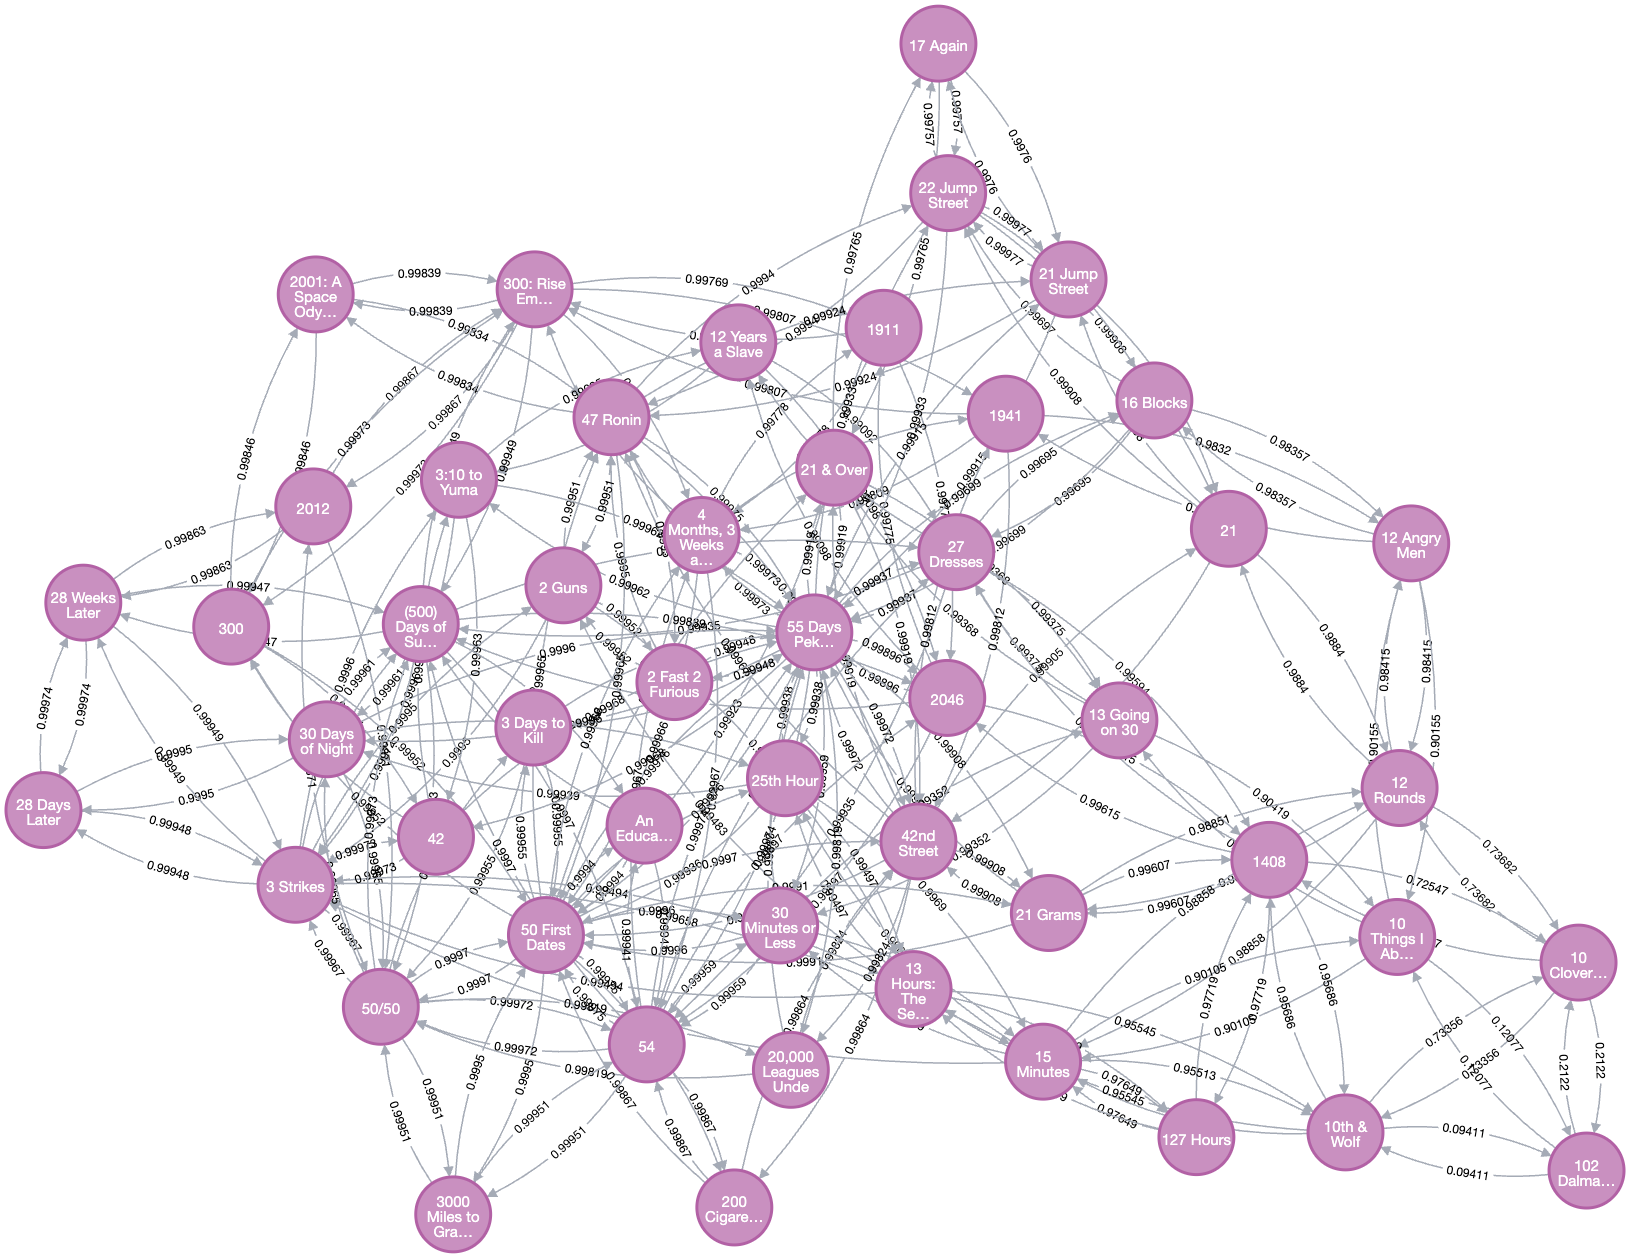

## Harmonic Centrality Analysis

In [18]:
query = "CALL gds.graph.drop('ds_graph', false) yield graphName"
session.run(query)

query = "CALL gds.graph.project('ds_graph', 'Movie', 'SIMILAR', {relationshipProperties: 'weight'})"
session.run(query)

In [19]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

my_neo4j_run_query_pandas(query)

,movie_title,closeness
0,55 Days at Peking,0.678571
1,50 First Dates,0.620748
2,54,0.566327
3,42nd Street,0.540816
4,(500) Days of Summer,0.532313
5,3 Strikes,0.528912
6,27 Dresses,0.527211
7,47 Ronin,0.522109
8,50/50,0.522109
9,2046,0.508503


# All movies in cleanmovies

In [20]:
# start fresh
my_neo4j_wipe_out_database()

my_neo4j_create_movie_nodes(movies_df, len(movies_df))
my_neo4j_create_top_3_similarity_links(movies_df, len(movies_df), similarities)
    
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,movie_title,labels
0,(500) Days of Summer,[Movie]
1,10 Cloverfield Lane,[Movie]
2,10 Things I Hate About You,[Movie]
3,102 Dalmatians,[Movie]
4,10th & Wolf,[Movie]
...,...,...
3218,[REC]²,[Movie]
3219,eXistenZ,[Movie]
3220,xXx,[Movie]
3221,xXx: State of the Union,[Movie]


-------------------------
  Relationships:
-------------------------


,movie_title_1,node_1_labels,relationship_type,movie_title_2,node_2_labels,similarity_score
0,(500) Days of Summer,[Movie],SIMILAR,Agora,[Movie],0.99979
1,(500) Days of Summer,[Movie],SIMILAR,Alatriste,[Movie],0.99979
2,(500) Days of Summer,[Movie],SIMILAR,Amélie,[Movie],0.99979
3,10 Cloverfield Lane,[Movie],SIMILAR,102 Dalmatians,[Movie],0.21220
4,10 Cloverfield Lane,[Movie],SIMILAR,10th & Wolf,[Movie],0.73356
...,...,...,...,...,...,...
17467,xXx: State of the Union,[Movie],SIMILAR,Zodiac,[Movie],1.00000
17468,Æon Flux,[Movie],SIMILAR,3000 Miles to Graceland,[Movie],0.99968
17469,Æon Flux,[Movie],SIMILAR,A Perfect Getaway,[Movie],0.99994
17470,Æon Flux,[Movie],SIMILAR,Argo,[Movie],0.99994


-------------------------
  Density: 0.0
-------------------------


## Harmonic Centrality Analysis

In [21]:
query = "CALL gds.graph.drop('ds_graph', false) yield graphName"
session.run(query)

query = "CALL gds.graph.project('ds_graph', 'Movie', 'SIMILAR', {relationshipProperties: 'weight'})"
session.run(query)

In [22]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

my_neo4j_run_query_pandas(query)

,movie_title,closeness
0,Warrior,0.292911
1,Vantage Point,0.289661
2,Zero Dark Thirty,0.286392
3,Zombieland,0.284853
4,You Kill Me,0.283099
...,...,...
3218,Batman & Robin,0.001241
3219,Final Destination 3,0.000931
3220,Final Destination 5,0.000931
3221,"First Love, Last Rites",0.000931


In [23]:
query = """

CALL gds.closeness.harmonic.stream('ds_graph', {})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).title AS movie_title, score as closeness
ORDER BY closeness DESC

"""

harmonic_centrality_closeness_df = my_neo4j_run_query_pandas(query)

In [24]:
harmonic_centrality_closeness_df.to_csv("Harmonic_Centrality_Analysis.csv")